Starting Parameter Optimization...
Target Risk: 0.020000
Frictionless Sharpe Ratio: 3.0
Base Impact Parameter (λ): 0.0035
Base Decay Rate (β): 2.0

Starting grid search...
Progress: 100/400 combinations processed
Progress: 200/400 combinations processed
Progress: 300/400 combinations processed
Progress: 400/400 combinations processed

Top 5 Parameter Combinations:

1. Parameter Set:
λ: 0.000316
β: 10.000000
γ: 0.257256
Sharpe: 83.7421
PnL: 26.5863
Risk: 0.0200
% of Frictionless SR: 2791.4%

2. Parameter Set:
λ: 0.000316
β: 8.858668
γ: 0.255178
Sharpe: 83.0103
PnL: 26.3542
Risk: 0.0200
% of Frictionless SR: 2767.0%

3. Parameter Set:
λ: 0.000357
β: 10.000000
γ: 0.254706
Sharpe: 82.8269
PnL: 26.2965
Risk: 0.0200
% of Frictionless SR: 2760.9%

4. Parameter Set:
λ: 0.000316
β: 7.847600
γ: 0.253007
Sharpe: 82.2493
PnL: 26.1137
Risk: 0.0200
% of Frictionless SR: 2741.6%

5. Parameter Set:
λ: 0.000357
β: 8.858668
γ: 0.252497
Sharpe: 82.0049
PnL: 26.0349
Risk: 0.0200
% of Frictionless SR: 2733

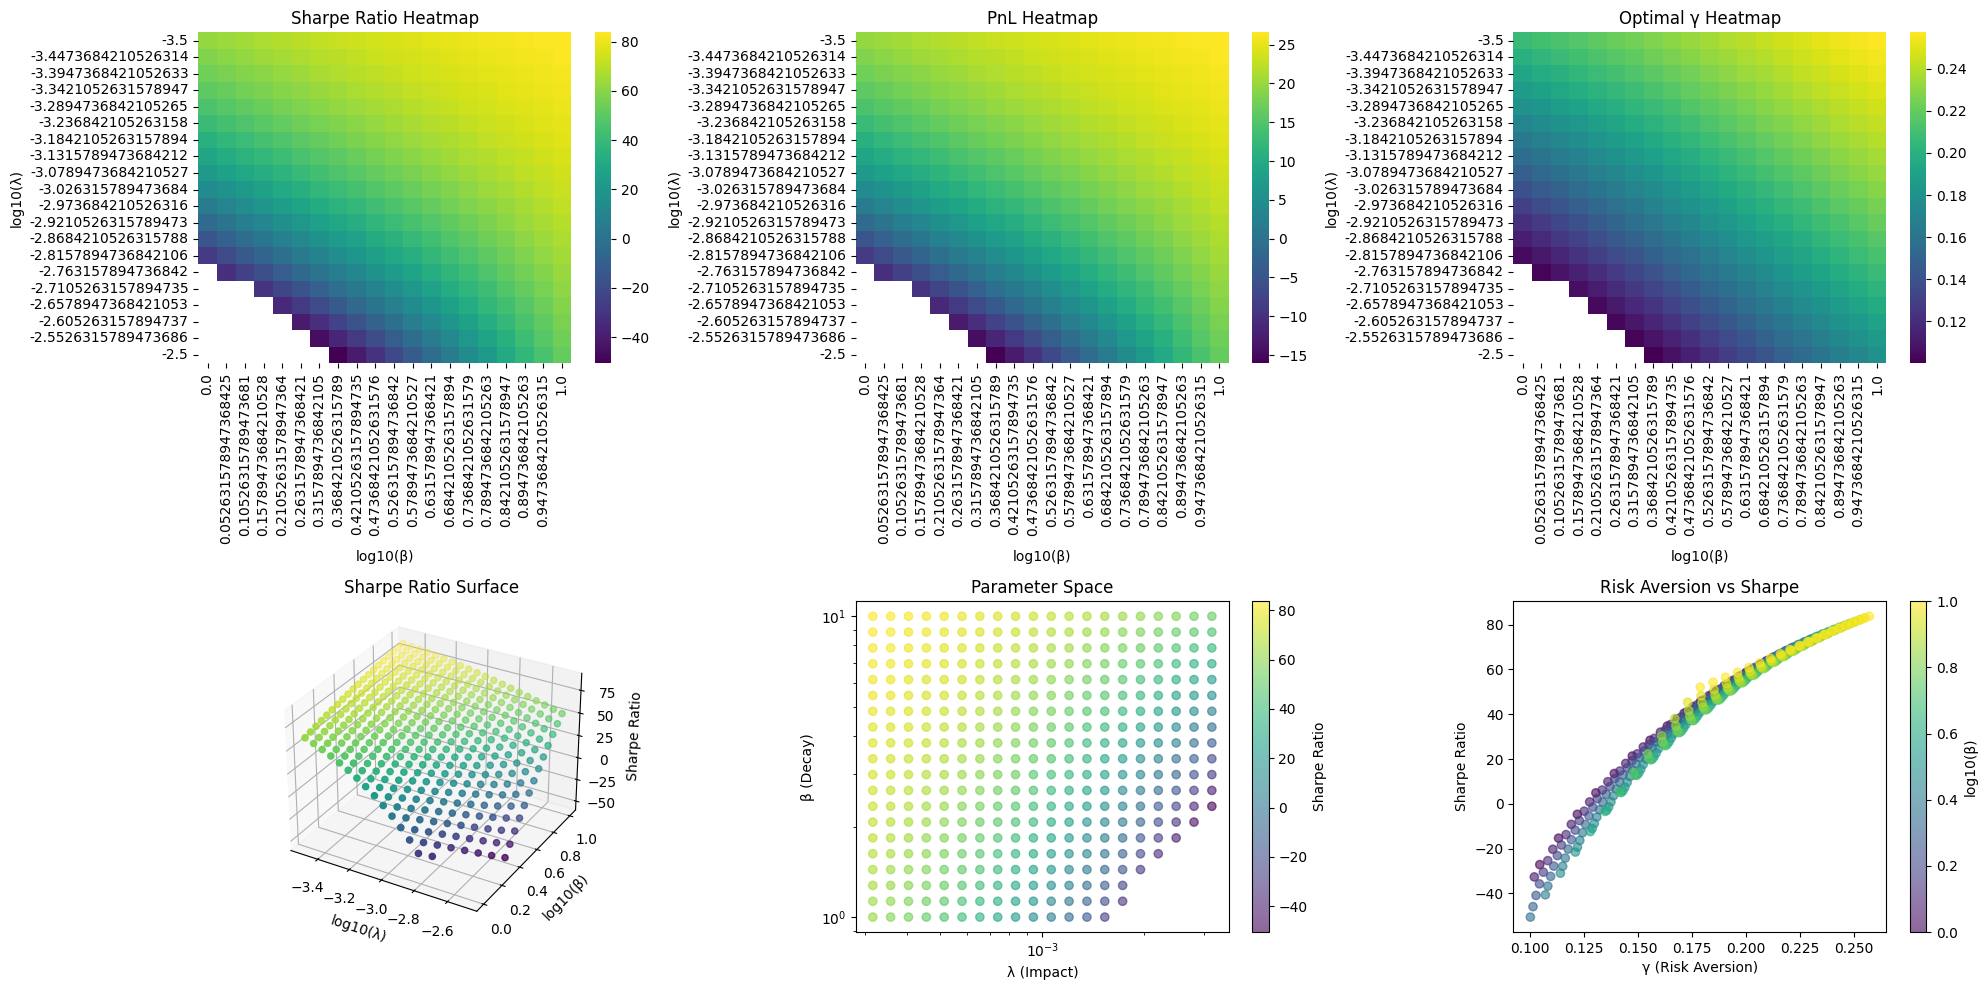

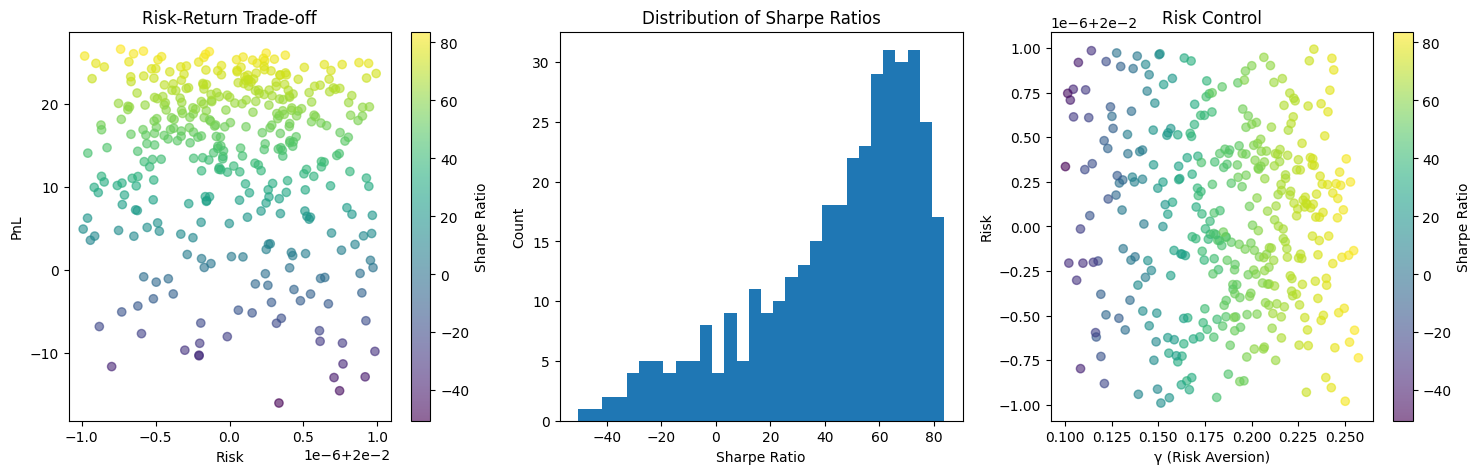

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Tuple, List, Dict
import pandas as pd
from scipy.special import gamma as gamma_function

@dataclass
class ModelParams:
    """Model parameters for the trading strategy"""
    alpha: float    # Signal scaling parameter
    sigma: float    # Volatility
    phi: float      # Signal mean reversion speed
    gamma: float    # Risk aversion
    beta: float     # Impact decay rate
    lambda_: float  # Impact coefficient
    p: float = 0.5  # Impact power law exponent (square root)
    n_assets: int = 500  # Number of assets

def calculate_performance(params: ModelParams) -> Tuple[float, float]:
    """
    Calculate performance using equation (5.6) for power law impact
    Returns PnL and risk
    """
    # Common terms
    beta_phi = params.beta/params.phi
    gamma_sigma2 = params.gamma * params.sigma**2
    xi = np.sqrt(gamma_sigma2 * (gamma_sigma2 + 2*params.lambda_*params.beta))
    
    # First term: expected returns (equation 5.6)
    returns = (params.alpha**2 * gamma_sigma2 * (params.beta + params.phi)**2) / \
             ((params.beta*gamma_sigma2 + xi*params.phi)**2)
    
    # Second term: trading costs for power law impact
    gamma_ratio = 2 * params.alpha**2 * gamma_sigma2**2 * params.phi
    beta_term = (params.beta**2 * xi + params.beta*params.phi*xi + 
                gamma_sigma2*params.beta*(params.beta + params.phi))
    denom = (xi*(params.beta + params.phi)*(gamma_sigma2*params.beta + 
            beta_term*xi)*(params.phi*xi + gamma_sigma2*params.beta)**3)
    
    cost_multiplier = gamma_function(0.5 * (params.p + 1))/(np.sqrt(np.pi))
    
    costs = (params.lambda_ * params.beta * cost_multiplier * 
            (gamma_ratio * (params.beta + params.phi)**2 * beta_term / 
             denom)**(params.p + 1)/2)
    
    # Net PnL (equation 5.6)
    pnl = (returns - costs) * params.n_assets * 252  # Annualized portfolio PnL
    
    # Calculate risk using equation (4.4)
    root_term = np.sqrt(1 + 2*params.lambda_*params.beta/gamma_sigma2)
    
    numerator = (params.alpha**2 * params.sigma**2 * (beta_phi + 1)**2 * 
                (beta_phi * root_term + 1))
    denominator = ((gamma_sigma2)**2 * root_term * 
                  (root_term + beta_phi)**3)
    
    # Single asset risk, then scale to portfolio and annualize
    single_asset_risk = np.sqrt(numerator/denominator)
    portfolio_risk = single_asset_risk * np.sqrt(252/params.n_assets)
    
    return pnl, portfolio_risk

def grid_search_parameters(base_params: ModelParams, 
                         target_risk: float,
                         n_points: int = 20) -> Tuple[ModelParams, List[Dict]]:
    """Search over grid of lambda and beta values to maximize Sharpe ratio"""
    # Parameter ranges from paper's calibration section
    lambda_grid = np.logspace(-3.5, -2.5, n_points)  # Around 0.0035
    beta_grid = np.logspace(0, 1, n_points)          # Around 2.0
    
    best_sharpe = -np.inf
    optimal_params = None
    all_results = []
    
    print("\nStarting grid search...")
    total_combinations = len(lambda_grid) * len(beta_grid)
    processed = 0
    
    for lambda_ in lambda_grid:
        for beta in beta_grid:
            # Binary search for gamma that achieves target risk
            gamma_low, gamma_high = 0.1, 10.0
            gamma = None
            converged = False
            
            for _ in range(20):
                gamma_try = (gamma_low + gamma_high) / 2
                params = ModelParams(**{**base_params.__dict__, 
                                     'gamma': gamma_try,
                                     'beta': beta,
                                     'lambda_': lambda_})
                
                try:
                    pnl, risk = calculate_performance(params)
                    
                    if abs(risk - target_risk) < 1e-6:
                        gamma = gamma_try
                        converged = True
                        break
                    elif risk > target_risk:
                        gamma_low = gamma_try
                    else:
                        gamma_high = gamma_try
                except:
                    break
            
            if converged:
                params = ModelParams(**{**base_params.__dict__, 
                                     'gamma': gamma,
                                     'beta': beta,
                                     'lambda_': lambda_})
                pnl, risk = calculate_performance(params)
                sharpe = pnl / (risk * np.sqrt(252))  # Annualized Sharpe
                
                result = {
                    'lambda': lambda_,
                    'beta': beta,
                    'gamma': gamma,
                    'sharpe': sharpe,
                    'pnl': pnl,
                    'risk': risk
                }
                all_results.append(result)
                
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    optimal_params = params
            
            processed += 1
            if processed % 100 == 0:
                print(f"Progress: {processed}/{total_combinations} combinations processed")
    
    # Print results
    print("\nTop 5 Parameter Combinations:")
    sorted_results = sorted(all_results, key=lambda x: x['sharpe'], reverse=True)[:5]
    for i, result in enumerate(sorted_results, 1):
        print(f"\n{i}. Parameter Set:")
        print(f"λ: {result['lambda']:.6f}")
        print(f"β: {result['beta']:.6f}")
        print(f"γ: {result['gamma']:.6f}")
        print(f"Sharpe: {result['sharpe']:.4f}")
        print(f"PnL: {result['pnl']:.4f}")
        print(f"Risk: {result['risk']:.4f}")
        print(f"% of Frictionless SR: {(result['sharpe']/3)*100:.1f}%")
    
    return optimal_params, all_results

def optimize_strategy_parameters():
    """Run parameter optimization with paper calibration"""
    # Parameters from Section 6.1
    base_params = ModelParams(
        alpha=1.67e-4,     # For SR=3
        sigma=0.02,        # Daily volatility
        phi=0.139,         # 5-day half life
        gamma=1.0,         # Placeholder
        beta=2.0,          # Paper's value
        lambda_=0.0035,    # Paper's value
        p=0.5,            # Square root impact
        n_assets=500       # Number of assets
    )
    
    target_risk = 0.02  # Portfolio volatility target
    
    print("Starting Parameter Optimization...")
    print(f"Target Risk: {target_risk:.6f}")
    print("Frictionless Sharpe Ratio: 3.0")
    print(f"Base Impact Parameter (λ): {base_params.lambda_}")
    print(f"Base Decay Rate (β): {base_params.beta}")
    
    return grid_search_parameters(base_params, target_risk)

def plot_parameter_landscape(results: List[Dict]):
    """Create visualizations of the parameter search results"""
    # Convert results to DataFrame
    df = pd.DataFrame(results)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 10))
    
    # 1. Heatmap of Sharpe ratio
    plt.subplot(231)
    pivot_sharpe = df.pivot_table(
        values='sharpe', 
        index=np.log10(df['lambda']), 
        columns=np.log10(df['beta']),
        aggfunc='mean'
    )
    sns.heatmap(pivot_sharpe, cmap='viridis', 
                xticklabels=True, yticklabels=True)
    plt.title('Sharpe Ratio Heatmap')
    plt.xlabel('log10(β)')
    plt.ylabel('log10(λ)')
    
    # 2. Heatmap of PnL
    plt.subplot(232)
    pivot_pnl = df.pivot_table(
        values='pnl',
        index=np.log10(df['lambda']),
        columns=np.log10(df['beta']),
        aggfunc='mean'
    )
    sns.heatmap(pivot_pnl, cmap='viridis',
                xticklabels=True, yticklabels=True)
    plt.title('PnL Heatmap')
    plt.xlabel('log10(β)')
    plt.ylabel('log10(λ)')
    
    # 3. Heatmap of optimal gamma
    plt.subplot(233)
    pivot_gamma = df.pivot_table(
        values='gamma',
        index=np.log10(df['lambda']),
        columns=np.log10(df['beta']),
        aggfunc='mean'
    )
    sns.heatmap(pivot_gamma, cmap='viridis',
                xticklabels=True, yticklabels=True)
    plt.title('Optimal γ Heatmap')
    plt.xlabel('log10(β)')
    plt.ylabel('log10(λ)')
    
    # 4. 3D surface plot of Sharpe ratio
    ax = fig.add_subplot(234, projection='3d')
    X = np.log10(df['lambda'])
    Y = np.log10(df['beta'])
    Z = df['sharpe']
    ax.scatter(X, Y, Z, c=Z, cmap='viridis')
    ax.set_xlabel('log10(λ)')
    ax.set_ylabel('log10(β)')
    ax.set_zlabel('Sharpe Ratio')
    plt.title('Sharpe Ratio Surface')
    
    # 5. Parameter relationships
    plt.subplot(235)
    plt.scatter(df['lambda'], df['beta'], c=df['sharpe'], 
                cmap='viridis', alpha=0.6)
    plt.xscale('log')
    plt.yscale('log')
    plt.colorbar(label='Sharpe Ratio')
    plt.xlabel('λ (Impact)')
    plt.ylabel('β (Decay)')
    plt.title('Parameter Space')
    
    # 6. Gamma vs Sharpe relationship
    plt.subplot(236)
    plt.scatter(df['gamma'], df['sharpe'], 
                c=np.log10(df['beta']), cmap='viridis', alpha=0.6)
    plt.colorbar(label='log10(β)')
    plt.xlabel('γ (Risk Aversion)')
    plt.ylabel('Sharpe Ratio')
    plt.title('Risk Aversion vs Sharpe')
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis plots
    plt.figure(figsize=(15, 5))
    
    # PnL vs Risk scatter
    plt.subplot(131)
    plt.scatter(df['risk'], df['pnl'], 
                c=df['sharpe'], cmap='viridis', alpha=0.6)
    plt.colorbar(label='Sharpe Ratio')
    plt.xlabel('Risk')
    plt.ylabel('PnL')
    plt.title('Risk-Return Trade-off')
    
    # Histogram of Sharpe ratios
    plt.subplot(132)
    plt.hist(df['sharpe'], bins=30)
    plt.xlabel('Sharpe Ratio')
    plt.ylabel('Count')
    plt.title('Distribution of Sharpe Ratios')
    
    # Risk vs Gamma
    plt.subplot(133)
    plt.scatter(df['gamma'], df['risk'],
                c=df['sharpe'], cmap='viridis', alpha=0.6)
    plt.colorbar(label='Sharpe Ratio')
    plt.xlabel('γ (Risk Aversion)')
    plt.ylabel('Risk')
    plt.title('Risk Control')
    
    plt.tight_layout()
    plt.show()

def optimize_strategy_parameters_with_viz():
    """Run parameter optimization with visualizations"""
    optimal_params, results = optimize_strategy_parameters()
    plot_parameter_landscape(results)
    return optimal_params, results

if __name__ == "__main__":
    # Run optimization with visualizations
    optimal_params, results = optimize_strategy_parameters_with_viz()